---
title: 'Expected Performance of a Mean-Reversion Trading Strategy - Part 3'
date: 2026-03-02
description: "How does a correlated bias in the fair-value estimate affect the Sharpe ratio of a mean-reversion strategy?"
categories: [Quantitative Finance, Trading Strategies, Stochastic Processes]
content-type: "series"
series-id: "mean-reversion-strategy"
series-title: "Expected Performance of a Mean-Reversion Trading Strategy"
series-part: 3
project-ids: [mean-reversion-strategy]
---

In [Part 1](../mean-reversion-strategy-1/index.qmd) we derived the asymptotic Sharpe ratio $\mathrm{SR}_\infty = \sqrt{\theta/2}$ for a mean-reversion strategy with perfect knowledge of fair value, and [Part 2](../mean-reversion-strategy-2/index.ipynb) showed that a constant bias $M$ in the fair-value estimate leaves expected PnL untouched while increasing path risk, producing a penalty factor $(1 + \xi^2)^{-1/2}$ where $\xi = M/s_\infty$ is the bias measured in units of the stationary mispricing scale $s_\infty = \sigma/\sqrt{2\theta}$.


In [ ]:
#| echo: false
#| output: false
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

rng = np.random.default_rng(42)

# --- OU helpers (same conventions as Parts 1–2) ---

def s2(t, theta, sigma):
    """Variance of X_t: sigma^2/(2*theta) * (1 - exp(-2*theta*t))."""
    return sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))


def simulate_ou(theta, sigma, T, dt, n_paths, rng=rng):
    """Euler–Maruyama: dX = -theta*X dt + sigma dW, X_0=0."""
    n_steps = int(T / dt)
    X = np.zeros((n_paths, n_steps + 1))
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        X[:, i + 1] = X[:, i] - theta * X[:, i] * dt + sigma * dW
    return X


def simulate_ou_ema(theta, sigma, lam, T, dt, n_paths, rng=rng):
    """Joint simulation of OU mispricing and EMA bias.

    dX = -theta*X dt + sigma dW,   X_0 = 0
    dM = lambda*(X - M) dt,        M_0 = 0
    """
    n_steps = int(T / dt)
    X = np.zeros((n_paths, n_steps + 1))
    M = np.zeros((n_paths, n_steps + 1))
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        X[:, i + 1] = X[:, i] - theta * X[:, i] * dt + sigma * dW
        M[:, i + 1] = M[:, i] + lam * (X[:, i] - M[:, i]) * dt
    return X, M


def pnl_paths(X, M, dt):
    """PnL paths: dY = -(X - M) dX.

    M can be: scalar, 1-D array (n_paths,) for per-path constant bias,
    or 2-D array (n_paths, n_steps+1) for time-varying bias.
    """
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    if np.ndim(M) == 2:
        M_mid = M[:, :-1]
    elif np.ndim(M) == 1:
        M_mid = M[:, None]
    else:
        M_mid = M
    dY = -(X_mid - M_mid) * dX
    Y = np.cumsum(dY, axis=1)
    return np.concatenate([np.zeros((X.shape[0], 1)), Y], axis=1)


print("Helpers loaded.")

Helpers loaded.


# Random Independent Bias

Before tackling correlated estimation error, it is useful to verify that the Part 2 penalty formula extends to a random bias drawn independently of the price process. Suppose the trader's bias $M$ is sampled once from a distribution $F$ with $\mathbb{E}[M]=0$ and $\mathbb{E}[M^2] = \sigma_M^2$, independently of the Brownian motion $\{W_t\}$. Each realisation of $M$ is a constant over the trading period, so conditionally on $M$ the PnL is exactly the Part 2 expression:

$$
Y_t = \frac{\sigma^2 t - X_t^2}{2} + M X_t.
$$

Since $M$ and $X_t$ are independent and $\mathbb{E}[X_t] = 0$, the expected PnL is unchanged:

$$
\mathbb{E}[Y_t] = \frac{\sigma^2 t - s_t^2}{2}.
$$

For path risk, the quadratic variation $d\langle Y\rangle_t = \sigma^2(X_t - M)^2\,dt$ gives, by the law of iterated expectation:

$$
\frac{1}{t}\,\mathbb{E}[\langle Y\rangle_t]
= \frac{1}{t}\int_0^t \sigma^2\bigl(\underbrace{\mathbb{E}[X_u^2]}_{s_u^2} + \underbrace{\mathbb{E}[M^2]}_{\sigma_M^2}\bigr)du
= \sigma^2 \sigma_M^2 + \frac{\sigma^2}{2\theta}\left(\sigma^2 - \frac{s_t^2}{t}\right).
$$

This is identical to Part 2's formula with $M^2$ replaced by $\mathbb{E}[M^2] = \sigma_M^2$. (Note that $\sigma_M^2$ here denotes the second moment $\mathbb{E}[M^2]$, which equals $\operatorname{Var}(M)$ only because $\mathbb{E}[M] = 0$. If the bias had a nonzero mean, the penalty would depend on the full second moment $\operatorname{Var}(M) + (\mathbb{E}[M])^2$.) Using the stationary mispricing scale $s_\infty = \sigma/\sqrt{2\theta}$ from Part 2, the asymptotic Sharpe ratio follows immediately:

$$
\boxed{
\mathrm{SR}_\infty
= \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \sigma_M^2/s_\infty^2}}.
}
$$

The conclusion reinforces Part 2: uncertainty in fair value increases path risk without affecting the expected return, and the Sharpe penalty depends only on $\mathbb{E}[M^2]$, regardless of the shape of $F$. @fig-random-bias confirms both predictions via Monte Carlo. The independence assumption, however, is the crucial one. As we show next, relaxing it changes the picture qualitatively.


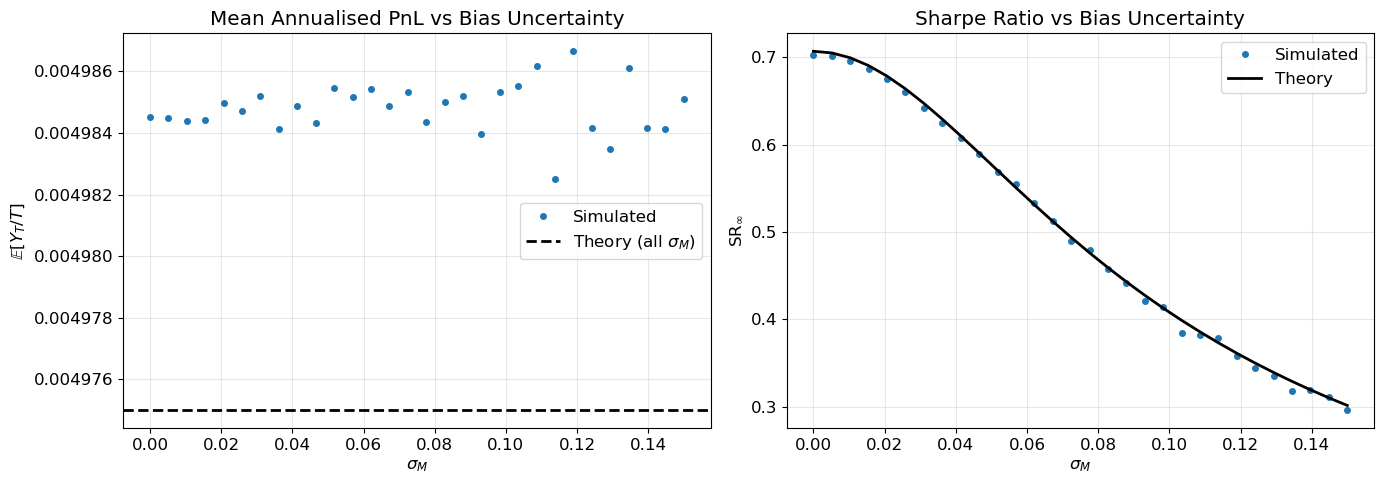

Left: expected PnL is invariant to bias uncertainty. Right: SR degrades with sigma_M.


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-random-bias
#| fig-cap: 'Random independent bias. Expected PnL is invariant to bias uncertainty (left). SR degrades with $\sigma_M$ following the same penalty formula as the constant-bias case (right).'
# --- Simulation: SR with random independent bias ---
theta, sigma, T, dt = 1.0, 0.10, 100, 1 / 252
n_paths = 3_000
X = simulate_ou(theta, sigma, T, dt, n_paths)

sigma_M_values = np.linspace(0, 0.15, 30)
rng_M = np.random.default_rng(99)

mean_pnls, sr_sim = [], []
for sm in sigma_M_values:
    M_draw = rng_M.normal(0, sm, size=n_paths) if sm > 0 else np.zeros(n_paths)
    Y = pnl_paths(X, M_draw, dt)
    mean_pnl = (Y[:, -1] / T).mean()
    mean_pnls.append(mean_pnl)

    dX = np.diff(X, axis=1)
    dY = -(X[:, :-1] - M_draw[:, None]) * dX
    qv = np.sum(dY**2, axis=1)
    sr_sim.append(mean_pnl / np.sqrt((qv / T).mean()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: mean annualised PnL vs sigma_M (should be flat)
theory_mean = 0.5 * (sigma**2 - s2(T, theta, sigma) / T)
axes[0].plot(sigma_M_values, mean_pnls, "o", ms=4, label="Simulated")
axes[0].axhline(theory_mean, color="k", ls="--", lw=2, label=r"Theory (all $\sigma_M$)")
axes[0].set(xlabel=r"$\sigma_M$", ylabel=r"$\mathbb{E}[Y_T/T]$",
            title="Mean Annualised PnL vs Bias Uncertainty")
axes[0].legend()

# Right: SR vs sigma_M (theory + MC)
sr_theory = np.sqrt(theta / 2) / np.sqrt(1 + 2 * theta * sigma_M_values**2 / sigma**2)
axes[1].plot(sigma_M_values, sr_sim, "o", ms=4, label="Simulated")
axes[1].plot(sigma_M_values, sr_theory, "k-", lw=2, label="Theory")
axes[1].set(xlabel=r"$\sigma_M$", ylabel=r"$\mathrm{SR}_\infty$",
            title="Sharpe Ratio vs Bias Uncertainty")
axes[1].legend()

print("Left: expected PnL is invariant to bias uncertainty. Right: SR degrades with sigma_M.")

plt.tight_layout()
plt.show()


# Time-Varying Correlated Bias

We now allow the bias $M_t$ to vary over time and to be correlated with the mispricing $X_t$. This is the practically relevant case: any estimate derived from the price history will, by construction, covary with price movements.

## Expected PnL with correlated bias

The PnL decomposition from Part 2 generalises to a time-varying bias:

$$
Y_t = \frac{\sigma^2 t - X_t^2}{2} + \int_0^t M_u\, dX_u.
$$

The structure is the same — an unbiased piece plus a bias-induced integral — but the second term is now a genuine Itô stochastic integral rather than the simple product $MX_t$ of the constant-bias case.

Substituting the OU dynamics $dX_u = -\theta X_u\, du + \sigma\, dW_u$:

$$
\mathbb{E}\!\left[\int_0^t M_u\, dX_u\right]
= -\theta \int_0^t \mathbb{E}[M_u X_u]\, du + \sigma\, \underbrace{\mathbb{E}\!\left[\int_0^t M_u\, dW_u\right]}_{=\, 0}.
$$

The stochastic integral $\int_0^t M_u\, dW_u$ has zero expectation by the martingale property (the integrand $M_u$ is adapted and satisfies $\mathbb{E}[\int_0^t M_u^2\, du] < \infty$, which holds for all the estimators considered below). Since $\mathbb{E}[X_u] = 0$, we have $\mathbb{E}[M_u X_u] = \operatorname{Cov}(M_u, X_u)$. The expected annualised PnL is therefore:

$$
\boxed{
\mathbb{E}\!\left[\frac{Y_t}{t}\right]
= \frac{1}{2}\left(\sigma^2 - \frac{s_t^2}{t}\right)
- \frac{\theta}{t}\int_0^t \operatorname{Cov}(M_u, X_u)\, du.
}
$$

This is the central result of the post. Compared to Parts 1–2, the expected PnL acquires a correction term proportional to the time-averaged covariance between the bias and the mispricing. Positive covariance — the bias and the mispricing moving in the same direction — reduces expected PnL: when the asset is overpriced ($X>0$), the bias also tends to be positive, so the trader under-estimates the overpricing and takes too small a position. Negative covariance would increase expected PnL, but this requires a contrarian estimator that anticipates mean reversion, a rare luxury in practice. Zero covariance recovers the Part 2 result, confirming that independent bias affects only risk.

## A contrast: proportional bias

To sharpen intuition for the EMA analysis that follows, consider the idealised case $M_t = \rho\, X_t$ for some $\rho \in [0,1)$. This assumes the trader has access to the true mispricing $X_t$ — making it a theoretical benchmark rather than a realisable estimator — but it provides a clean contrast with the EMA. The trader's perceived mispricing is then $\tilde{X}_t = (1-\rho)\,X_t$, and the PnL satisfies $Y_t = (1-\rho)\,(\sigma^2 t - X_t^2)/2$. Both the expected PnL and the path risk scale by $(1-\rho)$ and $(1-\rho)^2$ respectively, so the Sharpe ratio remains $\sqrt{\theta/2}$, independent of $\rho$. Proportional bias reduces capacity without degrading risk-adjusted return — a qualitatively different outcome from the lagged, asymmetric distortion introduced by trailing estimators.


# EMA Trailing Estimator

With the general covariance correction in hand, we now apply it to the most natural source of correlated bias: a trailing estimator of fair value. Suppose the trader estimates $\tilde{v}_t$ by exponentially smoothing past prices:

$$
d\tilde{v}_t = \lambda\,(p_t - \tilde{v}_t)\,dt, \qquad \tilde{v}_0 = v,
$$

where $\lambda > 0$ is the EMA decay rate. Since $p_t = v + X_t$ (constant fair value) and $\tilde{v}_t = v + M_t$, the bias $M_t = \tilde{v}_t - v$ satisfies

$$
dM_t = \lambda\,(X_t - M_t)\,dt, \qquad M_0 = 0.
$$

The bias is functionally determined by the path of $X$ — its dynamics have no independent $dW_t$ component, only a lagged response to the mispricing. The EMA half-life is $\ln 2/\lambda$. Unlike the proportional bias $M_t = \rho X_t$ discussed above, the EMA introduces a temporal lag: $M_t$ tracks $X_t$ with delay, and this asymmetry between the bias and the mispricing is what breaks the Sharpe-ratio invariance.

## Stationary moments

The joint system $(X_t, M_t)$ is a two-dimensional linear SDE, and its stationary second moments can be derived by applying the product rule and setting time derivatives to zero. (The joint system is exponentially ergodic — both eigenvalues of the drift matrix are strictly negative — so the time-averaged moments converge to these stationary values at an exponential rate.)

For $\mathbb{E}[X_t^2]$, Itô's formula gives $d(X^2) = (\sigma^2 - 2\theta X^2)\,dt + 2\sigma X\,dW$, so in stationarity:

$$
0 = \sigma^2 - 2\theta\,\Sigma_{XX} \;\;\Longrightarrow\;\; \Sigma_{XX} = \frac{\sigma^2}{2\theta}.
$$

For the cross-moment $\mathbb{E}[X_t M_t]$, the product rule yields $d(XM) = X\,dM + M\,dX = \bigl(\lambda X^2 - (\theta+\lambda)XM\bigr)dt + \sigma M\,dW$, giving:

$$
0 = \lambda\,\Sigma_{XX} - (\theta+\lambda)\,\Sigma_{XM}
\;\;\Longrightarrow\;\;
\Sigma_{XM} = \frac{\lambda}{\theta+\lambda}\,\Sigma_{XX}
= \frac{\lambda\sigma^2}{2\theta(\theta+\lambda)}.
$$

For $\mathbb{E}[M_t^2]$, since $d(M^2) = 2M\,dM = 2\lambda(XM - M^2)\,dt$:

$$
0 = 2\lambda\bigl(\Sigma_{XM} - \Sigma_{MM}\bigr)
\;\;\Longrightarrow\;\;
\Sigma_{MM} = \Sigma_{XM} = \frac{\lambda\sigma^2}{2\theta(\theta+\lambda)}.
$$

It is worth noting that $\Sigma_{MM} = \Sigma_{XM}$: the variance of the bias equals its covariance with the mispricing. This is a consequence of the deterministic dynamics of $M_t$ — the bias has no independent noise source, so all of its variability derives from its coupling to $X_t$. The stationary correlation between the bias and the mispricing is

$$
\operatorname{Corr}(M, X) = \frac{\Sigma_{XM}}{\sqrt{\Sigma_{XX}\,\Sigma_{MM}}} = \sqrt{\frac{\lambda}{\theta+\lambda}}.
$$

As $\lambda \to \infty$ (fast EMA), $\operatorname{Corr} \to 1$ and the bias tracks the mispricing almost perfectly. As $\lambda \to 0$ (slow EMA), $\operatorname{Corr} \to 0$ and the bias decouples from the mispricing. @fig-ema-cov-pnl confirms these stationary moments via Monte Carlo.

## Asymptotic expected PnL

Substituting $\Sigma_{XM}$ into the general covariance correction derived above:

$$
\mathbb{E}\!\left[\frac{Y_t}{t}\right]
\;\xrightarrow{t\to\infty}\;
\frac{\sigma^2}{2} - \theta\,\Sigma_{XM}
= \frac{\sigma^2}{2} - \frac{\lambda\sigma^2}{2(\theta+\lambda)}
= \frac{\sigma^2}{2}\cdot\frac{\theta}{\theta+\lambda}.
$$

$$
\boxed{
\text{Asymptotic mean PnL rate}
= \frac{\sigma^2\theta}{2(\theta+\lambda)}.
}
$$

The expected PnL is reduced by a factor $\theta/(\theta+\lambda)$ relative to the perfect-information benchmark $\sigma^2/2$. At $\lambda = \theta$ — when the EMA half-life matches the OU half-life — the expected PnL is exactly halved.

## Asymptotic quadratic variation

The stationary variance of the trader's signal $\tilde{X}_t = X_t - M_t$ determines the path risk:

$$
\operatorname{Var}(X-M) = \Sigma_{XX} - 2\Sigma_{XM} + \Sigma_{MM}
= \frac{\sigma^2}{2\theta} - \frac{\lambda\sigma^2}{2\theta(\theta+\lambda)}
= \frac{\sigma^2}{2(\theta+\lambda)},
$$

so the quadratic variation rate $\mathbb{E}[d\langle Y\rangle_t] = \sigma^2\,\mathbb{E}[(X_t-M_t)^2]\,dt$ yields

$$
\boxed{
\text{Asymptotic QV rate}
= \frac{\sigma^4}{2(\theta+\lambda)}.
}
$$

Both the numerator (expected PnL) and the denominator (path risk) of the Sharpe ratio are suppressed by the factor $1/(\theta+\lambda)$, but their ratio does not cancel — the square root in the denominator leaves a net penalty.

## Asymptotic Sharpe ratio

Combining the expected PnL and QV rates:

$$
\mathrm{SR}_\infty
= \frac{\sigma^2\theta/\bigl(2(\theta+\lambda)\bigr)}{\sqrt{\sigma^4/\bigl(2(\theta+\lambda)\bigr)}}
= \frac{\theta}{\sqrt{2(\theta+\lambda)}}.
$$

Factoring out the unbiased Sharpe from Part 1:

$$
\boxed{
\mathrm{SR}_\infty
= \sqrt{\frac{\theta}{2}} \cdot \sqrt{\frac{\theta}{\theta+\lambda}}
= \frac{\theta}{\sqrt{2(\theta+\lambda)}}.
}
$$

The penalty factor $\sqrt{\theta/(\theta+\lambda)}$ depends only on the ratio $\lambda/\theta$. At $\lambda = 0$ (no estimation) we recover the Part 1 result; at $\lambda = \theta$ the penalty is $1/\sqrt{2} \approx 0.71$; and as $\lambda \to \infty$ the EMA tracks the price too closely and the Sharpe ratio vanishes. @fig-sr-ema and @fig-ema-penalty confirm these predictions via Monte Carlo and display the universal penalty curve.

## Finite-horizon behaviour

The asymptotic results above use the stationary moments of the joint system. At finite horizons, the second moments of $(X_t, M_t)$ satisfy a $3\times 3$ linear ODE (the Lyapunov equation for the system's covariance matrix), which has closed-form exponential solutions. The resulting finite-horizon Sharpe ratio $\mathrm{SR}_t$ involves these time-dependent moments in place of $\Sigma_{XX}$, $\Sigma_{XM}$, and $\Sigma_{MM}$. @fig-sr-ema-horizon shows the convergence of $\mathrm{SR}_t$ to the asymptotic limit for several EMA decay rates; the exponential ergodicity of the joint system ensures convergence is rapid once $t$ exceeds a few multiples of the longer time-scale $1/\min(\theta, \lambda)$.


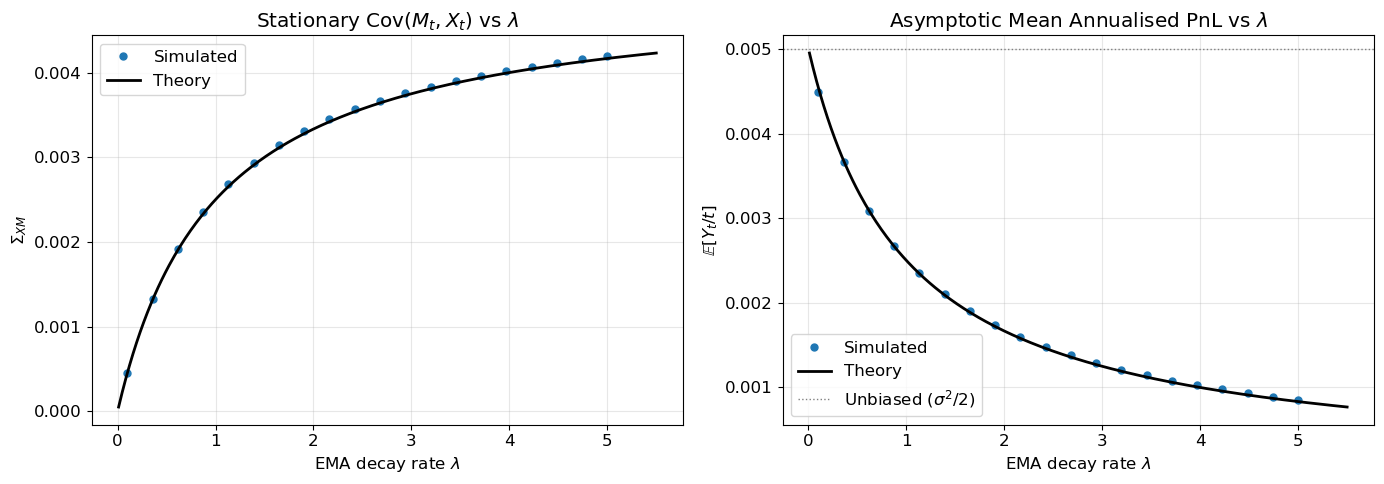

Unbiased PnL rate: 0.0050.  At lambda=theta=1.0: 0.0025 (halved).


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-ema-cov-pnl
#| fig-cap: "Stationary covariance and expected PnL vs EMA decay rate. Theory (solid lines) uses the closed‐form expressions; dots are Monte Carlo estimates."
# --- Stationary Cov(M,X) and expected PnL vs lambda ---
theta, sigma = 1.0, 0.10
T, dt, n_paths = 100, 1 / 252, 5_000

lam_scan = np.linspace(0.1, 10.0, 30)
cov_sim_list, pnl_sim_list = [], []

for lam in lam_scan:
    rng_sim = np.random.default_rng(42)
    X, M_arr = simulate_ou_ema(theta, sigma, lam, T, dt, n_paths, rng=rng_sim)
    # Stationary Cov from last portion of paths
    half = X.shape[1] // 2
    cov_sim = np.mean(X[:, half:] * M_arr[:, half:]) - np.mean(X[:, half:]) * np.mean(M_arr[:, half:])
    cov_sim_list.append(cov_sim)
    # Annualised PnL
    Y = pnl_paths(X, M_arr, dt)
    pnl_sim_list.append((Y[:, -1] / T).mean())

# Theory
lam_fine = np.linspace(0.01, 10.0, 200)
cov_theory = lam_fine * sigma**2 / (2 * theta * (theta + lam_fine))
pnl_theory = sigma**2 / 2 * theta / (theta + lam_fine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lam_scan, cov_sim_list, "o", ms=5, label="Simulated")
axes[0].plot(lam_fine, cov_theory, "k-", lw=2, label="Theory")
axes[0].set(xlabel=r"EMA decay rate $\lambda$",
            ylabel=r"$\Sigma_{XM}$",
            title=r"Stationary $\mathrm{Cov}(M_t, X_t)$ vs $\lambda$")
axes[0].legend()

axes[1].plot(lam_scan, pnl_sim_list, "o", ms=5, label="Simulated")
axes[1].plot(lam_fine, pnl_theory, "k-", lw=2, label="Theory")
axes[1].axhline(sigma**2 / 2, color="gray", ls=":", lw=1, label=r"Unbiased ($\sigma^2/2$)")
axes[1].set(xlabel=r"EMA decay rate $\lambda$",
            ylabel=r"$\mathbb{E}[Y_t/t]$",
            title="Asymptotic Mean Annualised PnL vs $\\lambda$")
axes[1].legend()

print(f"Unbiased PnL rate: {sigma**2/2:.4f}.  At lambda=theta={theta}: {sigma**2*theta/(2*(theta+theta)):.4f} (halved).")

plt.tight_layout()
plt.show()


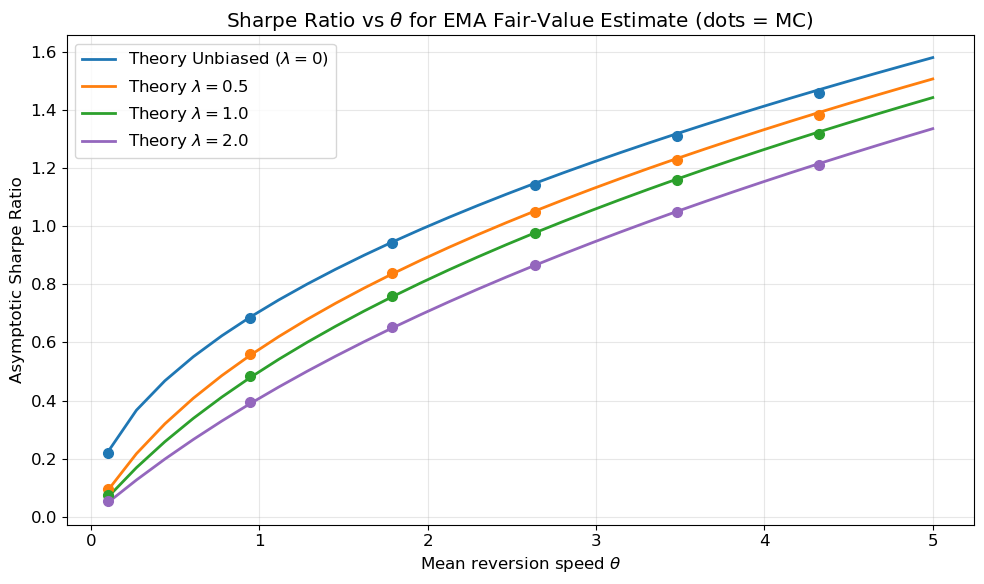

In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-ema
#| fig-cap: 'Sharpe ratio vs $\theta$ for different EMA decay rates. Lines are the closed-form $\theta/\sqrt{2(\theta+\lambda)}$; dots are Monte Carlo estimates.'
# --- SR vs theta for different EMA speeds ---
sigma = 0.10
T, dt, n_paths = 100, 1 / 252, 1_000
theta_range = np.linspace(0.1, 5.0, 30)
lam_values = [0.0, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10(np.linspace(0, 0.4, len(lam_values)))

for lam, c in zip(lam_values, colors):
    # Theory curve
    if lam == 0:
        sr_th = np.sqrt(theta_range / 2)
        label = r"Unbiased ($\lambda=0$)"
    else:
        sr_th = theta_range / np.sqrt(2 * (theta_range + lam))
        label = f"$\\lambda={lam}$"
    ax.plot(theta_range, sr_th, "-", color=c, lw=2, label=f"Theory {label}")

    # MC at subset of theta values
    theta_sim = theta_range[::5]
    sr_sim = []
    for th in theta_sim:
        seed_rng = np.random.default_rng(123)
        if lam == 0:
            X = simulate_ou(th, sigma, T, dt, n_paths, rng=seed_rng)
            M_arr = np.zeros_like(X)
        else:
            X, M_arr = simulate_ou_ema(th, sigma, lam, T, dt, n_paths, rng=seed_rng)
        Y = pnl_paths(X, M_arr, dt)
        mean_pnl = (Y[:, -1] / T).mean()

        dX = np.diff(X, axis=1)
        dY = -(X[:, :-1] - M_arr[:, :-1]) * dX
        qv = np.sum(dY**2, axis=1)
        sr_sim.append(mean_pnl / np.sqrt((qv / T).mean()))

    ax.plot(theta_sim, sr_sim, "o", color=c, ms=7, zorder=5)

ax.set(xlabel=r"Mean reversion speed $\theta$",
       ylabel="Asymptotic Sharpe Ratio",
       title=r"Sharpe Ratio vs $\theta$ for EMA Fair-Value Estimate (dots = MC)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


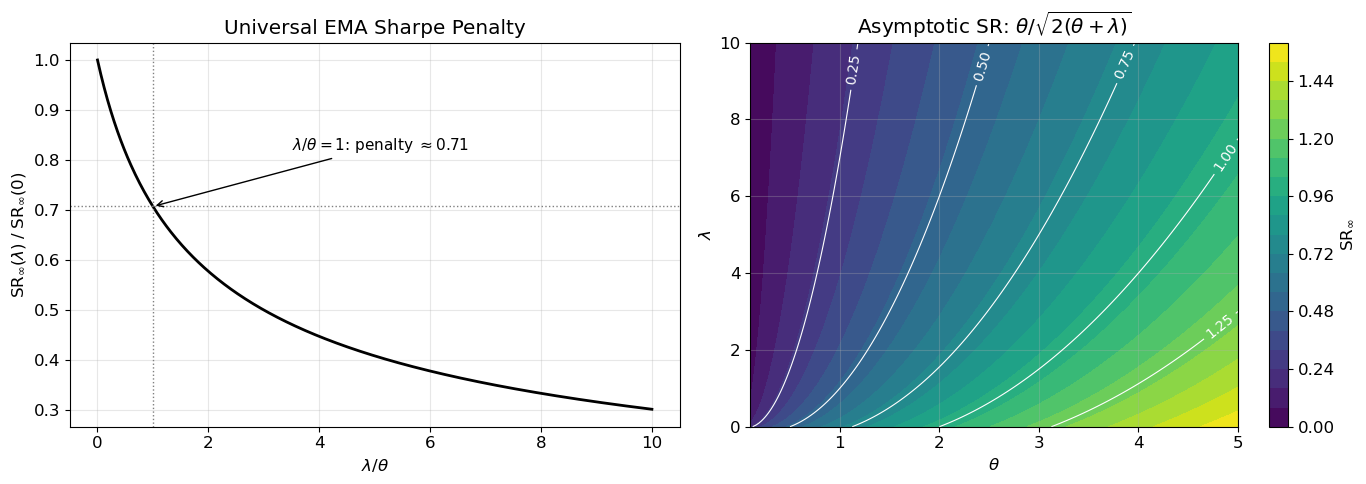

Left: penalty depends only on lambda/theta. Right: absolute SR over the (theta, lambda) plane.


In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-ema-penalty
#| fig-cap: "Left: the Sharpe-ratio penalty \\(\\sqrt{\\theta/(\\theta+\\lambda)}\\) depends only on the ratio \\(\\lambda/\\theta\\). Right: the absolute asymptotic Sharpe ratio \\(\\theta/\\sqrt{2(\\theta+\\lambda)}\\) over the \\((\\theta,\\lambda)\\) plane."
# --- EMA Sharpe-ratio penalty plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: penalty vs lambda/theta (universal curve)
ratio = np.linspace(0, 20, 500)
penalty = 1 / np.sqrt(1 + ratio)
axes[0].plot(ratio, penalty, "k-", lw=2)
axes[0].axhline(1 / np.sqrt(2), color="gray", ls=":", lw=1)
axes[0].text(1.5, 1 / np.sqrt(2) + 0.02, r"$1/\sqrt{2}$ at $\lambda=\theta$", fontsize=10)
axes[0].set(xlabel=r"$\lambda / \theta$",
            ylabel=r"Penalty $\sqrt{\theta/(\theta+\lambda)}$",
            title="Universal EMA Sharpe-Ratio Penalty")

# Right: heatmap of absolute SR = theta / sqrt(2*(theta+lambda))
theta_grid = np.linspace(0.1, 5.0, 200)
lam_grid = np.linspace(0.0, 10.0, 200)
Theta, Lam = np.meshgrid(theta_grid, lam_grid)
SR = Theta / np.sqrt(2 * (Theta + Lam))

cf = axes[1].contourf(Theta, Lam, SR, levels=20, cmap="viridis")
cs = axes[1].contour(Theta, Lam, SR, levels=[0.25, 0.5, 0.75, 1.0, 1.25],
                     colors="w", linewidths=0.8)
axes[1].clabel(cs, fmt="%.2f", fontsize=10)
plt.colorbar(cf, ax=axes[1], label=r"$\mathrm{SR}_\infty$")
axes[1].set(xlabel=r"$\theta$", ylabel=r"$\lambda$",
            title=r"Asymptotic SR: $\theta/\sqrt{2(\theta+\lambda)}$")

print("Left: penalty depends only on lambda/theta. Right: absolute SR over the (theta, lambda) plane.")

plt.tight_layout()
plt.show()


# All Linear Trailing Estimates Create Positive Correlation

The EMA penalty derived above is not specific to exponential weighting — it is an instance of a general result for linear estimators with non-negative kernels. Any trailing estimator of the form

$$
M_t = \int_0^t w(t-s)\, X_s\, ds, \qquad w \geq 0,\;\;\int_0^\infty w(s)\,ds = 1,
$$

produces a bias with non-negative covariance with the mispricing:

$$
\operatorname{Cov}(M_t, X_t)
= \int_0^t w(t-s)\,\operatorname{Cov}(X_s, X_t)\,ds.
$$

For the OU process, the autocovariance $\operatorname{Cov}(X_s, X_t) = s_s^2\, e^{-\theta(t-s)}$ is everywhere non-negative for $s \leq t$. Since both $w$ and the autocovariance are non-negative, the integral is non-negative — and strictly positive unless $w = 0$ almost everywhere, which corresponds to no estimation at all.

The EMA corresponds to exponential weights $w(u) = \lambda e^{-\lambda u}$; a simple moving average over a window $\tau$ uses rectangular weights $w(u) = 1/\tau$ for $u \in [0,\tau]$. In every case, the trailing estimate injects positive correlation, and the expected PnL falls below the perfect-information benchmark $\sigma^2/2$. The positive-correlation penalty is therefore not a modelling artefact of the EMA but an unavoidable cost of inferring fair value from price history via any linear estimator with non-negative weights. (Non-linear or sign-changing estimators could in principle achieve negative bias–mispricing covariance, but at the cost of introducing other distortions.) @fig-sr-ema-horizon illustrates the finite-horizon convergence of the Sharpe ratio for several EMA decay rates.


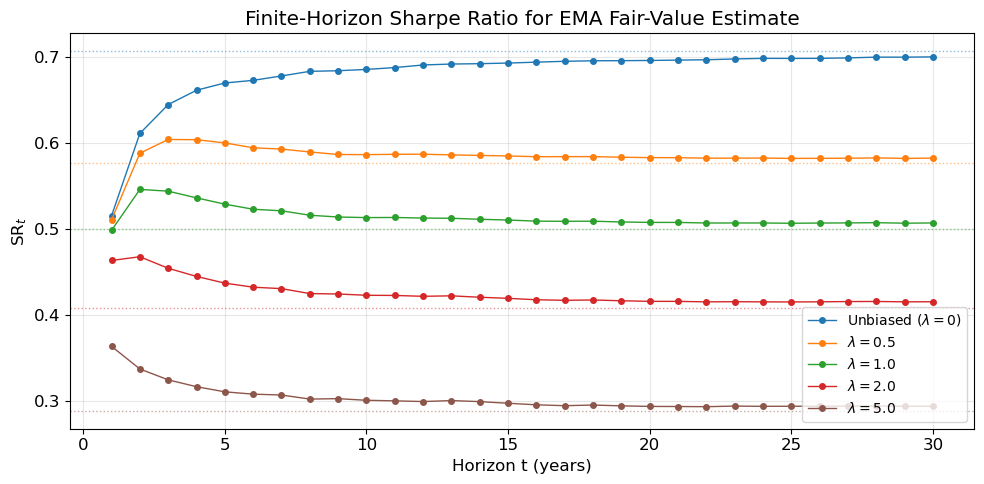

In [ ]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-ema-horizon
#| fig-cap: "Finite-horizon Sharpe ratio convergence for EMA fair-value estimates with different decay rates. Dotted horizontal lines show the asymptotic limits."
# --- Finite-horizon SR_t convergence for EMA ---
theta, sigma = 1.0, 0.10
T, dt, n_paths = 30, 1 / 252, 5_000
lam_values = [0.0, 0.5, 1.0, 2.0, 5.0]
eval_years = np.arange(1, int(T) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 0.5, len(lam_values)))

for lam, c in zip(lam_values, colors):
    # Simulate
    seed_rng = np.random.default_rng(42)
    if lam == 0:
        X = simulate_ou(theta, sigma, T, dt, n_paths, rng=seed_rng)
        M_arr = np.zeros_like(X)
        label = r"Unbiased ($\lambda=0$)"
    else:
        X, M_arr = simulate_ou_ema(theta, sigma, lam, T, dt, n_paths, rng=seed_rng)
        label = f"$\\lambda={lam}$"

    # Full PnL and cumulative QV
    Y = pnl_paths(X, M_arr, dt)
    dX = np.diff(X, axis=1)
    dY = -(X[:, :-1] - M_arr[:, :-1]) * dX
    cumQV = np.cumsum(dY**2, axis=1)

    sr_pts = []
    for yr in eval_years:
        idx = int(yr / dt)
        if idx >= X.shape[1]:
            break
        mean_ann = (Y[:, idx] / yr).mean()
        mean_qv_ann = (cumQV[:, idx - 1] / yr).mean()
        sr_pts.append(mean_ann / np.sqrt(mean_qv_ann))

    # Asymptotic limit
    sr_lim = np.sqrt(theta / 2) if lam == 0 else theta / np.sqrt(2 * (theta + lam))
    ax.axhline(sr_lim, color=c, ls=":", lw=1, alpha=0.5)
    ax.plot(eval_years[:len(sr_pts)], sr_pts, "o-", color=c, ms=4, lw=1, label=label)

ax.set(xlabel="Horizon t (years)", ylabel=r"$\mathrm{SR}_t$",
       title="Finite-Horizon Sharpe Ratio for EMA Fair-Value Estimate")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()


# Discussion

The key distinction established in this post is between independent and correlated estimation error. An independent bias — whether constant or random — leaves the expected PnL untouched and degrades only risk, exactly as in Part 2 (@fig-random-bias). A correlated bias, by contrast, directly reduces the expected return through the covariance correction $-(\theta/t)\int_0^t \operatorname{Cov}(M_u, X_u)\,du$, as demonstrated for the EMA trailing estimator in @fig-ema-cov-pnl. The mechanism is intuitive: when the trader's fair-value estimate co-moves with the price, the estimate chases the price rather than anchoring to true value, weakening the mean-reversion signal at its source.

The EMA Sharpe penalty $\sqrt{\theta/(\theta+\lambda)} = 1/\sqrt{1+\lambda/\theta}$ collapses to a universal curve in $\lambda/\theta$ (@fig-ema-penalty), yielding a practical rule of thumb: the EMA lookback (half-life $\ln 2/\lambda$) must be much longer than the OU half-life ($\ln 2/\theta$) — equivalently, $\lambda \ll \theta$ — for the estimation-induced penalty to remain small. At $\lambda = \theta$ the Sharpe ratio is roughly 71% of the unbiased level; @tbl-ema-penalty summarises the penalty across several values.

| $\lambda/\theta$ | 0 | 0.25 | 0.5 | 1 | 2 | 5 |
|---|---|---|---|---|---|---|
| Penalty | 1.00 | 0.89 | 0.82 | 0.71 | 0.58 | 0.41 |

: EMA Sharpe penalty for selected values of $\lambda/\theta$. {#tbl-ema-penalty}

The proportional-bias benchmark ($M_t = \rho X_t$) provides a useful contrast. In that case, both the PnL and QV scale by $(1-\rho)$ and $(1-\rho)^2$ respectively, and the Sharpe ratio cancels to $\sqrt{\theta/2}$ regardless of $\rho$. The EMA, however, introduces a lagged, asymmetric distortion — not a pure rescaling — and it is precisely this temporal asymmetry that degrades risk-adjusted return. The general trailing-estimate theorem then confirms that this penalty is not particular to exponential weighting: any non-negative kernel applied to an OU process produces positive correlation and therefore reduces expected PnL below the perfect-information benchmark.

# Further directions

Several extensions of this framework merit investigation. The analysis throughout assumes a constant fair value; when $v_t$ itself follows a random walk or trend, the OU dynamics of $X_t$ remain valid but the assumption $dp_t = dX_t$ breaks down, and the interplay between estimation bias and fair-value drift becomes considerably richer. A related question is the optimal choice of $\lambda$ in the presence of trading costs: the unbiased ($\lambda=0$) strategy generates the highest expected PnL but relies on continuous rebalancing, and some smoothing of fair value may actually improve net performance by reducing turnover.

It is also worth noting that the EMA is not the optimal estimator of the OU mean, even within the class of linear estimators. When $\theta$ and $\sigma$ are known, a Kalman filter (or equivalently, the MLE for the stationary OU mean) exploits the known dynamics to produce a lower-variance estimate and a correspondingly tighter lower bound on the estimation penalty. The EMA analysis above therefore represents an achievable but not best-case scenario for trailing estimation.

On the analytical side, the EMA has the cleanest closed-form results thanks to the Markov property of the joint system, but simple moving averages and other kernel estimators are common in practice; their qualitative behaviour follows from the general trailing-estimate result above, with quantitative differences depending on the kernel shape.

In the [next post](../mean-reversion-strategy-4/index.ipynb) we turn to a complementary source of error: uncertainty in the OU parameters $\theta$ and $\sigma$ themselves. Joint estimation of these parameters and fair value introduces additional correlations with the mispricing, and the rolling-estimation framework developed here will provide the analytical bridge between Parts 3 and 4.
